In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
alpha = pd.read_csv('alpha_da_rp.csv', index_col=0, parse_dates=True).squeeze()
alpha

datetime
2017-01-23 00:00:00+00:00   -1
2017-01-23 01:00:00+00:00    0
2017-01-23 02:00:00+00:00    0
2017-01-23 03:00:00+00:00    0
2017-01-23 04:00:00+00:00    0
                            ..
2025-01-01 01:00:00+00:00    0
2025-01-01 02:00:00+00:00    0
2025-01-01 03:00:00+00:00    0
2025-01-01 04:00:00+00:00    0
2025-01-01 05:00:00+00:00    0
Name: da-rp, Length: 69606, dtype: int64

In [4]:
returns = pd.read_csv('returns_da_rp.csv', index_col=0, parse_dates=True).squeeze()
returns

time
2017-01-01 06:00:00+00:00    0.005489
2017-01-01 07:00:00+00:00   -0.016269
2017-01-01 08:00:00+00:00    0.028522
2017-01-01 09:00:00+00:00    0.013500
2017-01-01 10:00:00+00:00   -0.005929
                               ...   
2025-01-01 01:00:00+00:00    0.034664
2025-01-01 02:00:00+00:00   -0.160854
2025-01-01 03:00:00+00:00   -0.119832
2025-01-01 04:00:00+00:00    0.054054
2025-01-01 05:00:00+00:00   -0.005027
Name: da-rp, Length: 70128, dtype: float64

In [5]:
alpha_filtered = alpha[alpha != 0]
alpha_filtered

datetime
2017-01-23 00:00:00+00:00   -1
2017-01-23 12:00:00+00:00   -1
2017-01-23 13:00:00+00:00   -1
2017-01-25 23:00:00+00:00   -1
2017-01-26 12:00:00+00:00   -1
                            ..
2024-12-23 23:00:00+00:00   -1
2024-12-27 23:00:00+00:00   -1
2024-12-28 00:00:00+00:00   -1
2024-12-28 01:00:00+00:00   -1
2024-12-29 23:00:00+00:00   -1
Name: da-rp, Length: 7788, dtype: int64

In [6]:
common_rows = alpha_filtered.index.intersection(returns.index)
common_rows

DatetimeIndex(['2017-01-23 00:00:00+00:00', '2017-01-23 12:00:00+00:00',
               '2017-01-23 13:00:00+00:00', '2017-01-25 23:00:00+00:00',
               '2017-01-26 12:00:00+00:00', '2017-01-27 12:00:00+00:00',
               '2017-01-30 00:00:00+00:00', '2017-01-30 12:00:00+00:00',
               '2017-02-03 12:00:00+00:00', '2017-02-06 00:00:00+00:00',
               ...
               '2024-12-23 09:00:00+00:00', '2024-12-23 16:00:00+00:00',
               '2024-12-23 17:00:00+00:00', '2024-12-23 18:00:00+00:00',
               '2024-12-23 19:00:00+00:00', '2024-12-23 23:00:00+00:00',
               '2024-12-27 23:00:00+00:00', '2024-12-28 00:00:00+00:00',
               '2024-12-28 01:00:00+00:00', '2024-12-29 23:00:00+00:00'],
              dtype='datetime64[ns, UTC]', length=7788, freq=None)

In [7]:
returns_filtered = returns.loc[common_rows]
returns_filtered

2017-01-23 00:00:00+00:00   -0.442139
2017-01-23 12:00:00+00:00   -0.340019
2017-01-23 13:00:00+00:00   -0.406053
2017-01-25 23:00:00+00:00   -0.462037
2017-01-26 12:00:00+00:00   -0.463890
                               ...   
2024-12-23 23:00:00+00:00   -0.316538
2024-12-27 23:00:00+00:00   -0.303369
2024-12-28 00:00:00+00:00   -0.372451
2024-12-28 01:00:00+00:00   -0.473417
2024-12-29 23:00:00+00:00   -0.379677
Name: da-rp, Length: 7788, dtype: float64

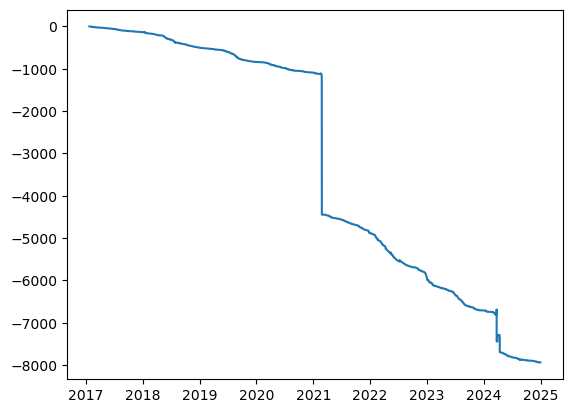

In [8]:
plt.plot(returns_filtered.cumsum())

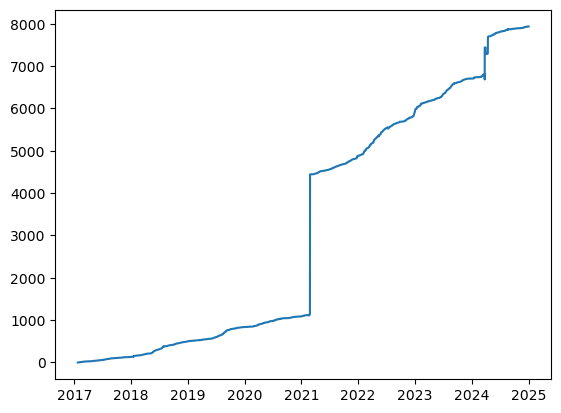

In [9]:
df = returns*alpha
first_valid = df.first_valid_index()
df = df.loc[first_valid:]
plt.plot(df.cumsum())
# plt.yscale('log')

c:\Users\qwane\miniforge3\envs\stat\Lib\site-packages\numpy\_core\fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


c:\Users\qwane\miniforge3\envs\stat\Lib\site-packages\matplotlib\ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


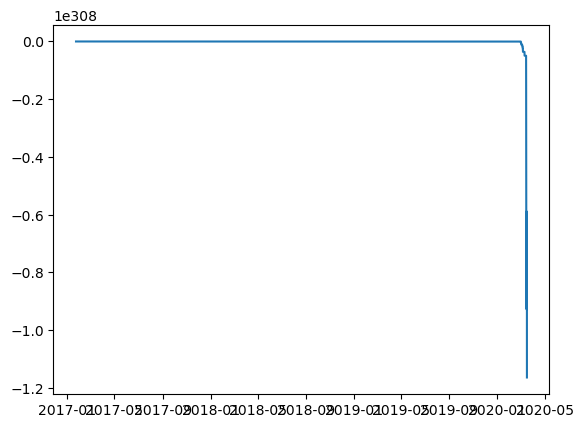

In [10]:
plt.plot((1+ df).cumprod())

In [11]:
annualized_return = df.mean() * 356*24
annualized_volatility = df.std() * np.sqrt(356*24)
sharpe_ratio = annualized_return / annualized_volatility
sharpe_ratio

np.float64(0.8492193728036552)

In [12]:
df

2017-01-23 00:00:00+00:00    0.442139
2017-01-23 01:00:00+00:00   -0.000000
2017-01-23 02:00:00+00:00   -0.000000
2017-01-23 03:00:00+00:00   -0.000000
2017-01-23 04:00:00+00:00   -0.000000
                               ...   
2025-01-01 01:00:00+00:00    0.000000
2025-01-01 02:00:00+00:00   -0.000000
2025-01-01 03:00:00+00:00   -0.000000
2025-01-01 04:00:00+00:00    0.000000
2025-01-01 05:00:00+00:00   -0.000000
Name: da-rp, Length: 69606, dtype: float64